In [25]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")


In [26]:
!gdown 1Zim4ODFec7nQqx5W_l8XzwzC_IB-3rmq -O CarPrice_Assignment.csv

cars = pd.read_csv("CarPrice_Assignment.csv")
cars.head()

Downloading...
From: https://drive.google.com/uc?id=1Zim4ODFec7nQqx5W_l8XzwzC_IB-3rmq
To: /content/CarPrice_Assignment.csv
100% 26.7k/26.7k [00:00<00:00, 58.8MB/s]


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [27]:
print("Shape:", cars.shape)
cars.info()

Shape: (205, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-n

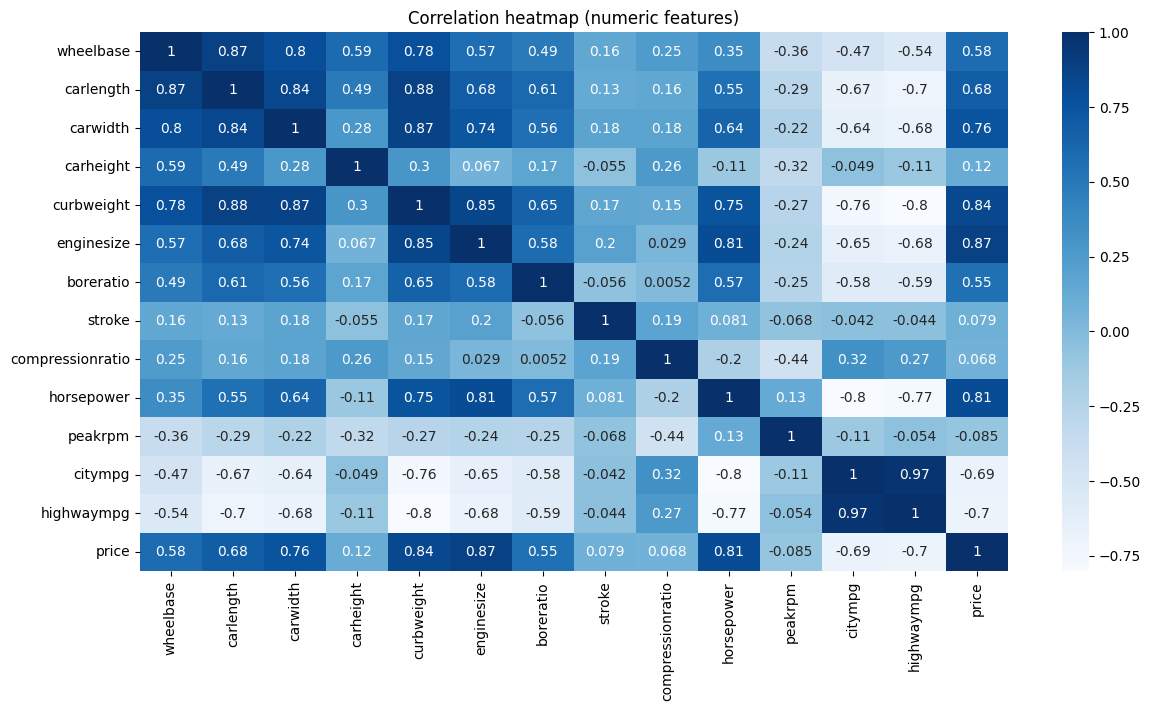

In [28]:
cars_numeric = cars.select_dtypes(include=["int64","float64"]).copy()


# Remove ID-like columns if present
for col in ["car_ID"]:
    if col in cars_numeric.columns:
        cars_numeric.drop(columns=[col], inplace=True)

# symboling is an integer, but it's really a small-category variable; treat as categorical later
if "symboling" in cars_numeric.columns:
    cars_numeric.drop(columns=["symboling"], inplace=True)

cor = cars_numeric.corr()


plt.figure(figsize=(14,7))
sns.heatmap(cor, cmap="Blues", annot=True)
plt.title("Correlation heatmap (numeric features)")
plt.show()



# Data Cleaning

In [29]:
cars.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [30]:
cars['CarName'][:100]

,CarName
0,alfa-romero giulia
1,alfa-romero stelvio
2,alfa-romero Quadrifoglio
3,audi 100 ls
4,audi 100ls
...,...
95,nissan juke
96,nissan latio
97,nissan note
98,nissan clipper


In [31]:
cars_clean = cars.copy()

# 3.1 Treat symboling as categorical (discrete risk index)
cars_clean["symboling"] = cars_clean["symboling"].astype("object")

cars_clean["car_company"] = cars_clean["CarName"].str.split(" ").str[0].str.lower()
# cars_clean["CarName"].apply(lambda x: x.split(" ")[0]).unique()




In [32]:
cars_clean['car_company'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [33]:
# fix a few common typos in this dataset
make_fixes = {
    "vw": "volkswagen",
    "vokswagen": "volkswagen",
    "porcshce": "porsche",
    "toyouta": "toyota",
    "nissan": "nissan",       # already lowercase after extract_make
    "maxda": "mazda",
}


cars_clean["car_company"] = cars_clean["car_company"].replace(make_fixes)

# 3.3 Drop CarName (raw text) and car_ID (pure identifier)
cars_clean = cars_clean.drop(columns=["CarName"])


cars_clean.head()

,car_ID,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,car_company
0,1,3,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,gas,std,two,convertible,rwd,front,88.6,168.8,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,gas,std,two,hatchback,rwd,front,94.5,171.2,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,gas,std,four,sedan,fwd,front,99.8,176.6,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,gas,std,four,sedan,4wd,front,99.4,176.6,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [34]:
if "car_ID" in cars_clean.columns:
    cars_clean = cars_clean.drop(columns=["car_ID"])

# let's split first, to prevent Lekage

In [35]:
# Features / target
X = cars_clean.drop(columns=["price"])
y = cars_clean["price"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

In [ ]:
# # First, split the data into training+validation and test sets (e.g., 70% train+val, 30% test)
# X_train_val, X_test, y_train_val, y_test = train_test_split(
#     X, y, test_size=0.3, random_state=42
# )

# # Then, split the training+validation set into training and validation sets
# # (e.g., 80% training of train_val set, 20% validation of train_val set)
# # This results in: Training ~56%, Validation ~14% of original data
# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_val, y_train_val, test_size=0.2, random_state=42
# )

# print("Train set shape:", X_train.shape, y_train.shape)
# print("Validation set shape:", X_val.shape, y_val.shape)
# print("Test set shape:", X_test.shape, y_test.shape)

## ColumnTransformer

In [36]:
toy = pd.DataFrame({
    "age": [18, 25, 40, 35],
    "income": [20_000, 45_000, 80_000, 60_000],
    "city": ["delhi", "delhi", "mumbai", "jaipur"],
    "owns_car": ["no", "yes", "yes", "no"],
})

toy_num = ["age", "income"]
toy_cat = ["city", "owns_car"]

toy

,age,income,city,owns_car
0,18,20000,delhi,no
1,25,45000,delhi,yes
2,40,80000,mumbai,yes
3,35,60000,jaipur,no


In [37]:
# Step 1: Scale numeric columns
scaler = StandardScaler()
toy_num_scaled = scaler.fit_transform(toy[toy_num])
toy_num_scaled_df = pd.DataFrame(toy_num_scaled, columns=[f"scaled_{c}" for c in toy_num])

print("After scaling numeric columns:")
display(toy_num_scaled_df)
print()

After scaling numeric columns:


,scaled_age,scaled_income
0,-1.343674,-1.426825
1,-0.525786,-0.285365
2,1.226833,1.312679
3,0.642627,0.399511


In [38]:
# Step 2: One-hot encode categorical columns
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
toy_cat_encoded = encoder.fit_transform(toy[toy_cat])

toy_cat_encoded_df = pd.DataFrame(
    toy_cat_encoded,
    columns=encoder.get_feature_names_out(toy_cat)
)

print("After one-hot encoding categorical columns:")
display(toy_cat_encoded_df)
print()

After one-hot encoding categorical columns:


,city_delhi,city_jaipur,city_mumbai,owns_car_no,owns_car_yes
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,1.0
3,0.0,1.0,0.0,1.0,0.0


In [39]:
# Step 3: Combine them manually
toy_manual = pd.concat([toy_num_scaled_df, toy_cat_encoded_df], axis=1)

print("Manually combined:")
display(toy_manual)

Manually combined:


,scaled_age,scaled_income,city_delhi,city_jaipur,city_mumbai,owns_car_no,owns_car_yes
0,-1.343674,-1.426825,1.0,0.0,0.0,1.0,0.0
1,-0.525786,-0.285365,1.0,0.0,0.0,0.0,1.0
2,1.226833,1.312679,0.0,0.0,1.0,0.0,1.0
3,0.642627,0.399511,0.0,1.0,0.0,1.0,0.0


In [40]:
toy_num = ["age", "income"]
toy_cat = ["city", "owns_car"]


ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)


toy_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), toy_num),
        ("cat", ohe, toy_cat)
        ],
    remainder="drop"
).set_output(transform="pandas")

toy_transformed = toy_preprocess.fit_transform(toy)
toy_transformed


,num__age,num__income,cat__city_delhi,cat__city_jaipur,cat__city_mumbai,cat__owns_car_no,cat__owns_car_yes
0,-1.343674,-1.426825,1.0,0.0,0.0,1.0,0.0
1,-0.525786,-0.285365,1.0,0.0,0.0,0.0,1.0
2,1.226833,1.312679,0.0,0.0,1.0,0.0,1.0
3,0.642627,0.399511,0.0,1.0,0.0,1.0,0.0


## Coming back to our cars case-study

In [41]:
num_cols = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("\nExample numeric:", num_cols[:8])
print("Example categorical:", cat_cols[:8])

Numeric columns: 13
Categorical columns: 11

Example numeric: ['wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke']
Example categorical: ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype']


In [42]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)


preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop",
).set_output(transform="pandas")


# Demonstrate shapes (fit only on train, transform test) "pp" = preprocessed
X_train_pp = preprocess.fit_transform(X_train)
X_test_pp = preprocess.transform(X_test)


print("Preprocessed train shape:", X_train_pp.shape)
print("Preprocessed test shape :", X_test_pp.shape)

X_train_pp.head()

Preprocessed train shape: (143, 77)
Preprocessed test shape : (62, 77)


,num__wheelbase,num__carlength,num__carwidth,num__carheight,num__curbweight,num__enginesize,num__boreratio,num__stroke,num__compressionratio,num__horsepower,...,cat__car_company_nissan,cat__car_company_peugeot,cat__car_company_plymouth,cat__car_company_porsche,cat__car_company_renault,cat__car_company_saab,cat__car_company_subaru,cat__car_company_toyota,cat__car_company_volkswagen,cat__car_company_volvo
177,0.573309,0.076413,0.235105,0.043859,-0.221382,-0.121429,-0.038909,0.921956,-0.344056,-0.340756,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
75,0.622875,0.302880,0.924984,0.408026,0.646950,0.314497,1.692945,-0.448994,-0.531628,1.723785,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
174,0.573309,0.076413,0.235105,0.448489,-0.179118,-0.412047,-0.186301,0.301764,3.353784,-0.813362,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
31,-2.037199,-2.430901,-0.960684,-1.210497,-1.448956,-0.847973,-1.512828,0.497614,-0.210076,-0.738740,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12,0.375042,0.173470,-0.546757,0.205711,0.262732,0.895732,-0.038909,-0.220503,-0.263668,0.380589,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
linreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

linreg_pipe.fit(X_train, y_train)

pred_train = linreg_pipe.predict(X_train)
pred_test  = linreg_pipe.predict(X_test)


print("Linear Regression")
print("  Train R2 :", r2_score(y_train, pred_train))
print("  Test  R2 :", r2_score(y_test, pred_test))
print("  Test MSE: ", mean_squared_error(y_test, pred_test))

Linear Regression
  Train R2 : 0.9786249443259047
  Test  R2 : 0.8890733062476718
  Test MSE:  7685487.048033528


In [44]:
def eval_regression(pipe, name: str):
    pipe.fit(X_train, y_train)
    pred_test = pipe.predict(X_test)
    return {
        "model": name,
        "train_r2": r2_score(y_train, pipe.predict(X_train)),
        "test_r2": r2_score(y_test, pred_test),

        "test_mse": mean_squared_error(y_test, pred_test)
    }

ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=10.0, random_state=42))
])


results = [
    eval_regression(linreg_pipe, "LinearRegression"),
    eval_regression(ridge_pipe, "Ridge(alpha=10)"),

]
pd.DataFrame(results)


,model,train_r2,test_r2,test_mse
0,LinearRegression,0.978625,0.889073,7.685487e+06
1,Ridge(alpha=10),0.935029,0.851998,1.025424e+07


In [45]:
# K-Fold setup (shuffle=True is important for most tabular datasets)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 9.1 Ridge tuning
ridge_tune_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(random_state=100000000))
])


ridge_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 3, 10, 30, 100, 300, 1000]
}


ridge_grid = GridSearchCV(
    estimator=ridge_tune_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_mean_squared_log_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=0
)


ridge_grid.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_["model__alpha"])
print("Best CV score (neg MAE):", ridge_grid.best_score_)

Best Ridge alpha: 1
Best CV score (neg MAE): -0.029338794912909222


In [46]:
# Evaluate best ridge on test set
best_ridge = ridge_grid.best_estimator_
pred_test = best_ridge.predict(X_test)

print("Best Ridge")
print(" Train R2 :", r2_score(y_train, best_ridge.predict(X_train)))
print("  Test R2 :", r2_score(y_test, pred_test))
print("  Test MSE:", mean_squared_error(y_test, pred_test))


Best Ridge
 Train R2 : 0.9709844998243002
  Test R2 : 0.8912227413356884
  Test MSE: 7536564.773595025


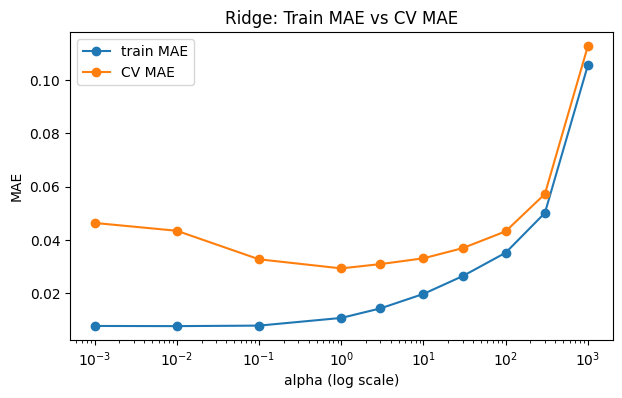

In [47]:
def plot_grid(grid, title):
    df = pd.DataFrame(grid.cv_results_).copy()
    # Convert neg MAE to MAE for readability (multiply by -1)
    df["mean_train_mae"] = -df["mean_train_score"]
    df["mean_val_mae"]   = -df["mean_test_score"]
    df["alpha"] = df["param_model__alpha"].astype(float)

    df = df.sort_values("alpha")

    plt.figure(figsize=(7,4))
    plt.plot(df["alpha"], df["mean_train_mae"], marker="o")
    plt.plot(df["alpha"], df["mean_val_mae"], marker="o")
    plt.xscale("log")
    plt.xlabel("alpha (log scale)")
    plt.ylabel("MAE")
    plt.title(title)
    plt.legend(["train MAE", "CV MAE"])
    plt.show()

plot_grid(ridge_grid, "Ridge: Train MAE vs CV MAE")


In [48]:
std = StandardScaler()

dir(std)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__slotnames__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_reset',
 '_sklearn_auto_wrap_output_keys',
 '_validate_data',
 '_validate_params',
 'copy',
 'fit',
 'fit_transform',
 'get_feature_names_out',
 'ge

In [49]:
import numpy as np
from sklearn.model_selection import KFold

X = ["a", "b", "c", "d"]
kf = KFold(n_splits=2)
for train, test in kf.split(X):
    print("%s %s" % (train, test))

[2 3] [0 1]
[0 1] [2 3]
